# Orange County Analysis

In [1]:
# Import statements
import pandas as pd

from utils import (
    load_census,
    add_standardized_race,
    census_rollup,
    policing_summary_table,
    prosecution_rates_by_statute_level,
    visualize_policing,
    visualize_prosecution
)

# Display all columns
pd.set_option('display.max_columns', None)

# Import Data

In [ ]:
# Load in policing data
full_policing = pd.read_csv("../data/cleaned/cleaned_orange_ripa_2019_2024.csv")

# Select only relevant columns to use
keep_cols = [
    "doj_record_id",
    "person_number",
    "agency_ori",
    "agency_name",
    "time_of_stop",
    "date_of_stop",
    "stop_duration",
    "closest_city",
    "race_ethnicity",
    "gender",
    "age",
    "reason_for_contact",
    "traffic_violation_cjis_offense_code",
    "suspicion_cjis_offense_code",
    "suspicion",
    "search_basis_plain_view",
    "search_basis_plain_smell",
    "search_basis_consent",
    "search_basis_safety",
    "search_basis_suspect_weapon",
    "search_basis_evidence_of_crime",
    "search_basis_school_policy",
    "search_basis_emergency",
    "search_basis_canine",
    "search_basis_warrant",
    "search_basis_probation",
    "search_basis_incident_to_arrest",
    "search_basis_vehicle_inventory",
    "contraband_any",
    "result_of_stop_arrest",
    "search_type",
    "multi_person_stop"
]
policing = full_policing[[c for c in keep_cols if c in full_policing.columns]].copy()


# Filter for only discretionary stops
policing = policing[policing["reason_for_contact"].isin([
    "Moving violation",
    "Equipment violation",
    "Non-moving violation",
    "Suspect criminal activity"
])]

<positron-console-cell-2>:2: DtypeWarning: Columns (0: time_of_stop, 1: closest_city, 2: school_code, 3: school_name, 4: ros_warning_cds, 5: ros_citation_cds, 6: ros_in_field_cite_release_cds, 7: ros_custodial_wout_warrant_cds, 8: loc_closest_city, 9: ros_verbal_warning_cds, 10: ros_written_warning_cds) have mixed types. Specify dtype option on import or set low_memory=False.


In [3]:
# Load in prosecution data
prosecution = pd.read_csv("https://raw.githubusercontent.com/laurenbchu/honors-thesis/main/data/cleaned/cleaned_orange_aclu_2021_2023.csv", low_memory=False)
prosecution['filed_date'] = pd.to_datetime(prosecution["filed_date"])
prosecution['Year'] = prosecution['filed_date'].dt.year

In [4]:
# Load in census data
census = load_census("06059")

# Policing Analysis

In [ ]:
# Add standardized race column to match policing and prosecution labels
policing = add_standardized_race(policing, "race_ethnicity")

# Roll-up census data to be more coarse to match policing/prosecution race categories
census_coarse = census_rollup(census)

# Adds counts, rates, and per-capita rates for stops, searches, and hits
policing_analysis = policing_summary_table(policing, census_coarse)

policing_analysis

,Year,Perceived Race,Stop Count,Search Count,Hit Count,Search Rate,Hit Rate,Population,"Stops per 1,000","Searches per 1,000"
0,2019,Asian,3001,111,53,0.036988,0.477477,699124,4.292515,0.158770
1,2019,Black/African American,1785,257,102,0.143978,0.396887,49304,36.203959,5.212559
2,2019,Hispanic/Latino,14412,2047,806,0.142034,0.393747,1086834,13.260535,1.883452
3,2019,Other,3613,116,46,0.032106,0.396552,153072,23.603272,0.757813
4,2019,White,23042,2480,1160,0.107630,0.467742,1198655,19.223213,2.068986
5,2020,Asian,2356,123,54,0.052207,0.439024,699124,3.369932,0.175934
6,2020,Black/African American,1381,217,108,0.157133,0.497696,49304,28.009898,4.401266
7,2020,Hispanic/Latino,11782,2023,885,0.171703,0.437469,1086834,10.840662,1.861370
8,2020,Other,2632,135,56,0.051292,0.414815,153072,17.194523,0.881938
9,2020,White,16917,1955,1015,0.115564,0.519182,1198655,14.113319,1.630995


## Prosecution Rates

In [6]:
# Standardize race labels to match with policing data
prosecution = add_standardized_race(prosecution, "canonical_race")

# Create race x year x statute_level prosecution summary table
prosecution_analysis = prosecution_rates_by_statute_level(prosecution)

prosecution_analysis

,Canonical Race,Year,statute_level,Total Charges,Charge Rate,Enhancement Rate
0,Asian,2021,Felony,1251,1.0,0.000799
1,Asian,2021,Infraction,2,1.0,0.000000
2,Asian,2021,Misdemeanor,2768,1.0,0.142702
3,Asian,2022,Felony,1090,1.0,0.003670
4,Asian,2022,Infraction,4,1.0,0.000000
5,Asian,2022,Misdemeanor,2289,1.0,0.174749
6,Asian,2023,Felony,876,1.0,0.001142
7,Asian,2023,Infraction,3,1.0,0.000000
8,Asian,2023,Misdemeanor,1325,1.0,0.163774
9,Black/African American,2021,Felony,1689,1.0,0.008289


# Visualizations

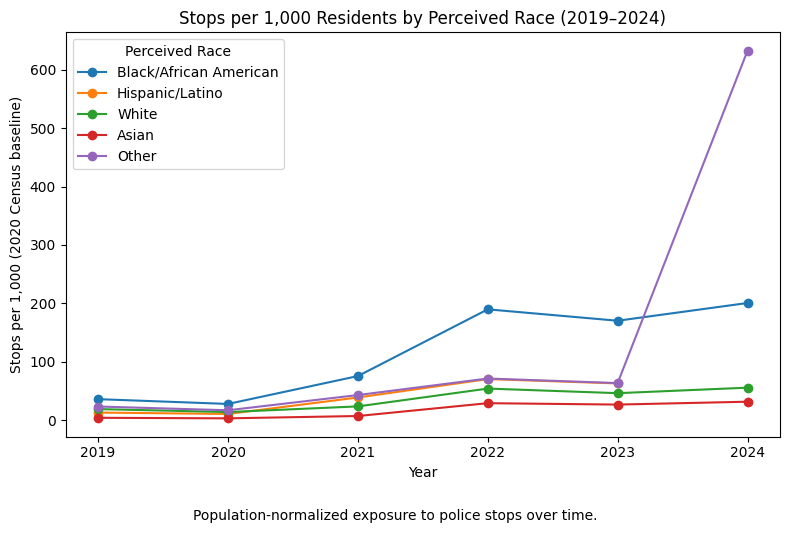

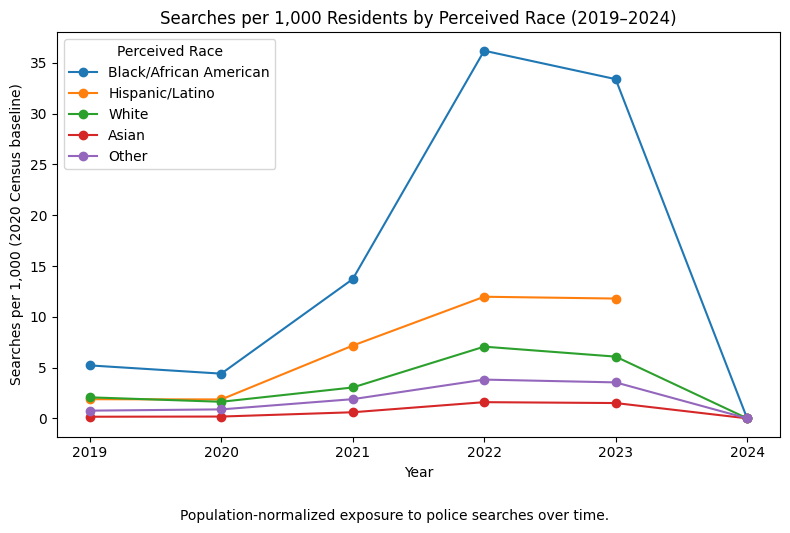

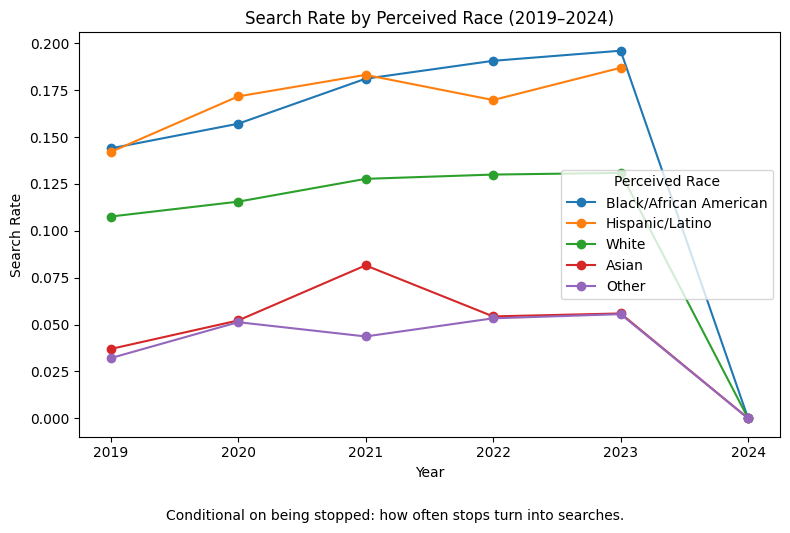

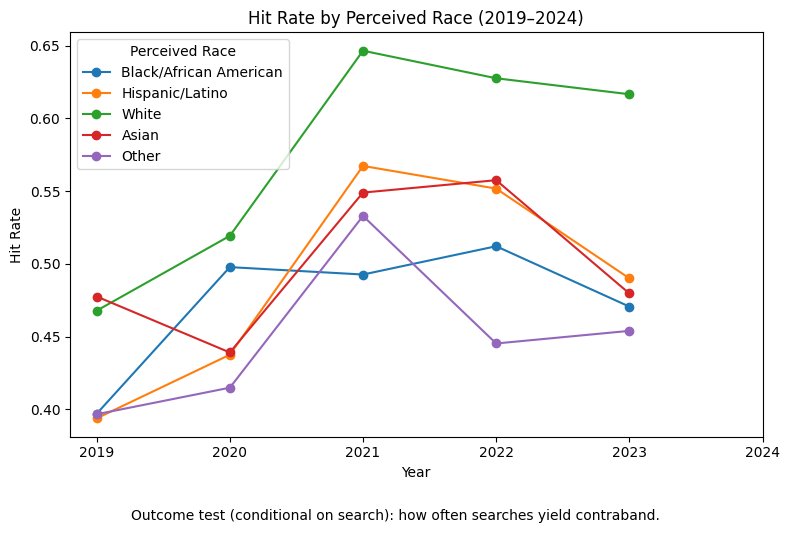

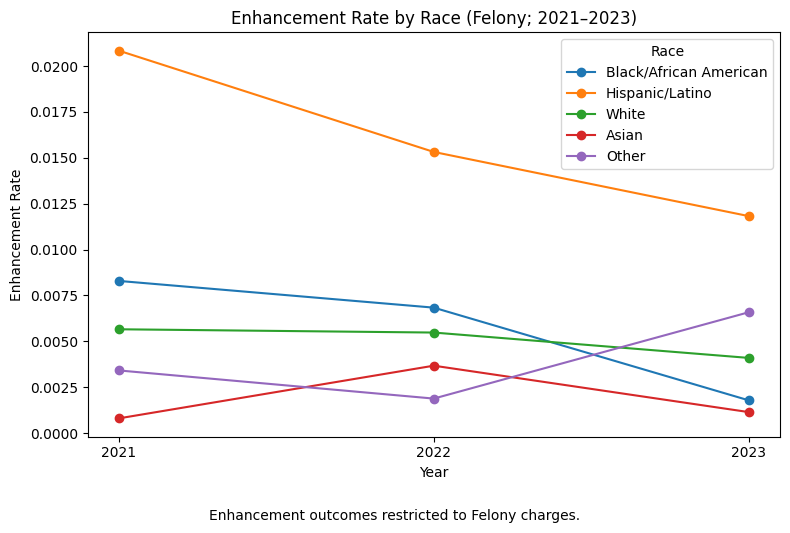

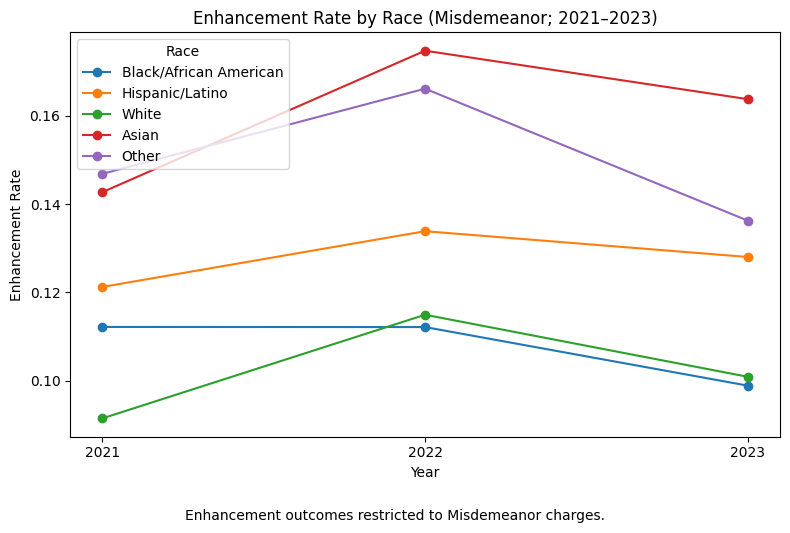

In [ ]:
visualize_policing(policing_analysis)
visualize_prosecution(prosecution_analysis)

# Anomaly Investigation
- Why does Other suddenly skyrocket in 2024 for stops per 1,000 residents?
- Why is 2019 so low for Black/African American stops per 1,000 residents and then a gap is created in the years following?
- What happens with Black/African American stops in 2024? Why is it near zero and doesn't follow the trend of previous years?
- Something is wrong with the 2024 data. Why is there no hit rate data for the 2024 data. Is the 2024 data formatted differently?

In [ ]:
policing

necessary_cols = [
    "doj_record_id",
    "person_number",
    "agency_name",
    "time_of_stop",
    "date_of_stop",
    "stop_duration",z
    "closest_city",
    ""
]

,doj_record_id,person_number,agency_ori,agency_name,time_of_stop,date_of_stop,stop_duration,closest_city,school_code,school_name,stop_student,k12_school_grounds,rae_full,rae_asian,rae_black_african_american,rae_hispanic_latino,rae_middle_eastern_south_asian,rae_native_american,rae_pacific_islander,rae_white,rae_multiracial,g_full,g_male,g_female,g_transgender_man,g_transgender_woman,g_gender_nonconforming,g_multigender,lgbt,age,age_group,limited_english_fluency,pd_full,pd_deafness_hearing,pd_speech_impair,pd_blind,pd_mental_health,pd_devel_disab,pd_hyperactivity_disability,pd_other,pd_none_disability,pd_disab_multi,reason_for_stop,rfs_traffic_violation_type,rfs_traffic_violation_code,rfs_rs_code,rfs_rs_off_witness,rfs_rs_match_suspect,rfs_rs_witness_id,rfs_rs_carry_sus_object,rfs_rs_actions_indicative,rfs_rs_suspect_look,rfs_rs_drug_trans,rfs_rs_violent_crime,rfs_rs_reason_susp,rfs_ec_discipline_code,rfs_ec_discipline,call_for_service,ads_removed_vehicle_order,ads_removed_vehicle_phycontact,ads_sobriety_test,ads_curb_detent,ads_handcuffed,ads_patcar_detent,ads_canine_search,ads_firearm_point,ads_firearm_discharge,ads_elect_device,ads_impact_discharge,ads_canine_bite,ads_baton,ads_chem_spray,ads_other_contact,ads_photo,ads_asked_search_per,ads_search_person,ads_asked_search_prop,ads_search_property,ads_prop_seize,ads_vehicle_impound,ads_written_statement,ads_no_actions,ads_search_pers_consen,ads_search_prop_consen,bfs_consent_given,bfs_officer_safety,bfs_search_warrant,bfs_parole,bfs_suspect_weapon,bfs_visible_contraband,bfs_odor_contraband,bfs_canine_detect,bfs_evidence,bfs_incident,bfs_exigent_circum,bfs_vehicle_invent,bfs_school_policy,ced_none_contraband,ced_firearm,ced_ammunition,ced_weapon,ced_drugs,ced_alcohol,ced_money,ced_drug_paraphernalia,ced_stolen_prop,ced_elect_device,ced_other_contraband,bps_safekeeping,bps_contraband,bps_evidence,bps_impound_vehicle,bps_abandon_prop,bps_violate_school,tps_firearm,tps_ammunition,tps_weapon,tps_drugs,tps_alcohol,tps_money,tps_drug_paraphernalia,tps_stolen_prop,tps_cellphone,tps_vehicle,tps_contraband,ros_no_action,ros_warning,ros_citation,ros_in_field_cite_release,ros_custodial_warrant,ros_custodial_without_warrant,ros_field_interview_card,ros_noncriminal_transport,ros_contact_legal_guardian,ros_psych_hold,ros_us_homeland,ros_referral_school_admin,ros_referral_school_counselor,ros_warning_cds,ros_citation_cds,ros_in_field_cite_release_cds,ros_custodial_wout_warrant_cds,year,pd_multi,non_reporting_agency,loc_closest_city,rae_hispanic_latinex,g_cisgender_man,g_cisgender_woman,g_nonbinary_person,sor_lgb,sor_straight,person_unhoused,passenger_in_vehicle,inside_residence,welfare_wellness_check,tos_vehicular,tos_bicycle,tos_pedestrian,rfs_rs_match_vehicle,rfs_pc_off_witness,rfs_pc_match_suspect,rfs_pc_witness_id,rfs_pc_carry_sus_object,rfs_pc_actions_indicative,rfs_pc_suspect_look,rfs_pc_drug_trans,rfs_pc_violent_crime,rfs_pc_reason_susp,rfs_pc_match_vehicle,rfs_pc_code,rfs_rg_traffic_moving,rfs_rg_traffic_equipment,rfs_rg_traffic_non_moving,rfs_rg_off_witness,rfs_rg_match_suspect,rfs_rg_match_vehicle,rfs_rg_witness_id,rfs_rg_carry_sus_object,rfs_rg_actions_indicative,rfs_rg_suspect_look,rfs_rg_drug_trans,rfs_rg_violent_crime,rfs_rg_reason_susp,rfs_rg_probable_cause,rfs_rg_welfare_and_inst,rfs_rg_known_parole,rfs_rg_outstanding_warrant,rfs_rg_truant,rfs_rg_consensual_search,rfs_rg_discipline,rfs_rg_school_policy,rfs_rg_not_communicated,nfa_written_statement,nfa_asked_search_per,nfa_asked_search_prop,nfa_asked_id_passenger,nfa_asked_parole,nfa_curb_detent,nfa_sobriety_test,nfa_patcar_detent,nfa_canine_search,nfa_photo,nfa_removed_vehicle_order,nfa_prop_seize,nfa_ran_name_passenger,nfa_search_person,nfa_search_property,nfa_terry_frisk,nfa_vehicle_impound,nfa_none,nfa_search_pers_consent,nfa_search_prop_consent,ofa_handcuffed,ofa_baton_drawn,ofa_baton_used,ofa_chem_spray,ofa_elect_device_point,ofa_elect_device_stun,ofa_elect_device_dart,ofa_firearm_unholstered,ofa_firearm_point,ofa_firearm